# EU Coverage — AoI Composition with Set Operations

Demonstrates how to build a complex **Area of Interest** from geographic
building blocks using AoI set operations, then runs a coverage study over
all 27 EU member states.

**AoI operations used**

| Operator | Meaning | Example use |
|:--------:|---------|-------------|
| `\|` | union — area covered by *either* AoI | combine 26 countries + Belgium |
| `&` | intersection — area common to *both* AoIs | clip to continental bounding box |
| `-` | difference — area in self *not* in other | strip overseas territories |

**Belgium** is a special case in the Natural Earth dataset: it is split into
three administrative regions (*Flemish*, *Walloon*, *Brussels*) rather than a
single country unit.  We union them back together before adding Belgium to the
EU composite.

**Scenario**
- 550 km sun-synchronous orbit, LTAN 10:30 (ascending)
- 15° half-angle nadir sensor
- Analysis window: 30 days
- AoI: continental EU (overseas territories excluded via bounding-box intersection)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

from missiontools import Spacecraft, Sensor, AoI, Coverage
from missiontools.plotting import plot_coverage_map

## 1. Build the EU AoI

### 1a. Belgium — union of three regions

The Natural Earth dataset represents Belgium as three separate map units.
The `|` operator unions them into a single geometry without materialising
any sample points yet (points are generated lazily on first access).

In [2]:
belgium = (
    AoI.from_geography('Flemish')
    | AoI.from_geography('Walloon')
    | AoI.from_geography('Brussels')
)
print(f"Belgium  : {belgium}")

Belgium  : AoI(not yet sampled, Polygon)


### 1b. Full EU — union of all 27 member states

We chain the `|` operator across all members.  Each call is O(1) — it
merely composes Shapely geometries; no sampling happens until the AoI's
points are requested.

In [3]:
EU_MEMBERS = [
    'Germany', 'France',      'Italy',    'Spain',    'Poland',
    'Netherlands', 'Portugal', 'Greece',  'Sweden',   'Austria',
    'Denmark', 'Finland',    'Ireland',   'Czechia',  'Romania',
    'Hungary', 'Slovakia',   'Bulgaria',  'Croatia',  'Slovenia',
    'Lithuania', 'Latvia',   'Estonia',   'Luxembourg', 'Malta', 'Cyprus',
]

eu = belgium
for member in EU_MEMBERS:
    eu = eu | AoI.from_geography(member)

print(f"EU (full) : {eu}")
print(f"           — no points sampled yet; geometry composed lazily")

EU (full) : AoI(not yet sampled, MultiPolygon)
           — no points sampled yet; geometry composed lazily


### 1c. Continental EU — intersection with bounding box

Several member states include overseas territories far from the European
continent (e.g. French Guiana, Réunion, Martinique, Madeira, the Canaries).
We use the `&` operator to intersect the full EU geometry with a
continental bounding box, retaining only the parts inside it.

The box (27°N – 72°N, 32°W – 45°E) keeps all mainland territories plus
the Azores and Cyprus while excluding equatorial and southern-hemisphere
departments.

In [4]:
POINT_DENSITY = 5_000   # km² per sample point

continental_box = AoI.from_region(
    lat_min_deg = 27.0,
    lat_max_deg = 72.0,
    lon_min_deg = -32.0,
    lon_max_deg =  45.0,
    point_density = POINT_DENSITY,
)

eu_continental = eu & continental_box
print(f"EU (continental) : {eu_continental}")
print(f"  {len(eu_continental)} sample points  "
      f"(~{POINT_DENSITY:,} km²/point)")

EU (continental) : AoI(not yet sampled, MultiPolygon)
  52 sample points  (~5,000 km²/point)


### 1d. Difference operator — EU without high-latitude Scandinavia

The `-` operator removes one geometry from another.  Here we demonstrate
it by carving out the region above 60°N to obtain a "temperate EU" AoI.
*(Not used in the coverage study below — shown for illustration.)*

In [5]:
arctic_strip = AoI.from_region(lat_min_deg=60.0, point_density=POINT_DENSITY)
eu_temperate = eu_continental - arctic_strip

print(f"EU continental   : {len(eu_continental):>5} sample points")
print(f"EU temperate     : {len(eu_temperate):>5} sample points  (below 60°N)")
print(f"Difference       : {len(eu_continental) - len(eu_temperate):>5} points removed  "
      f"(~{(len(eu_continental) - len(eu_temperate)) / len(eu_continental) * 100:.0f}% of AoI)")

EU continental   :    52 sample points
EU temperate     :    45 sample points  (below 60°N)
Difference       :     7 points removed  (~13% of AoI)


## 2. AoI Sample Point Map

Visualise the three AoIs side by side to confirm the set operations.

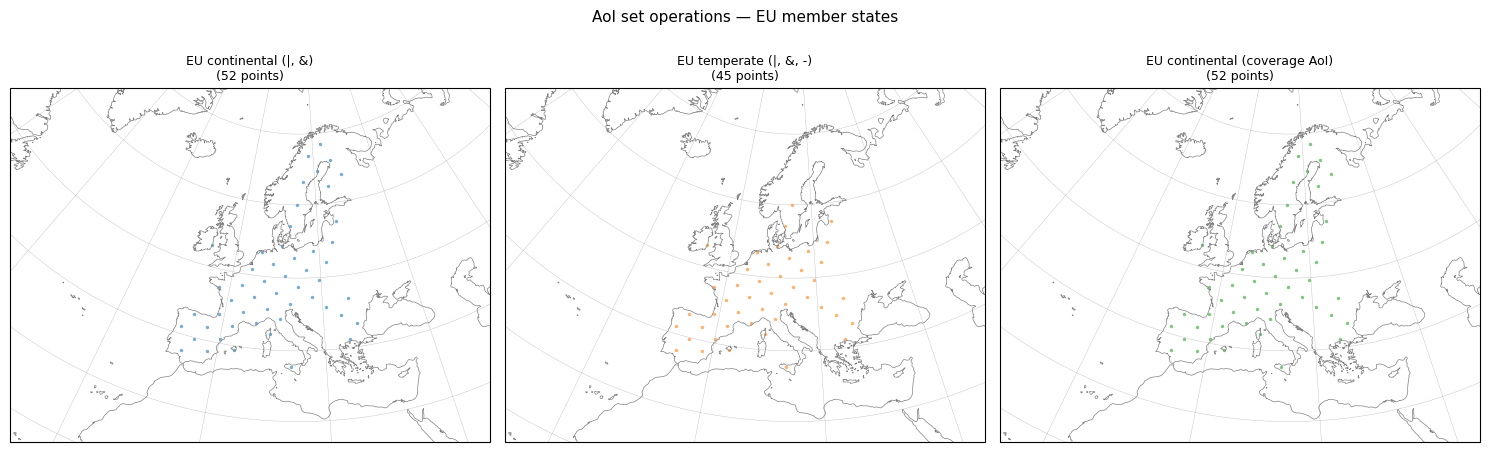

In [6]:
europe_proj = ccrs.AlbersEqualArea(
    central_longitude = 15.0,
    central_latitude  = 52.0,
    standard_parallels = (35.0, 65.0),
)

fig, axes = plt.subplots(
    1, 3, figsize=(15, 5),
    subplot_kw={'projection': europe_proj},
)

aois   = [eu_continental,         eu_temperate,          eu_continental]
titles = ['EU continental (|, &)', 'EU temperate (|, &, -)', 'EU continental (coverage AoI)']
colors = ['tab:blue',              'tab:orange',            'tab:green']

for ax, aoi, title, color in zip(axes, aois, titles, colors):
    ax.set_extent([-32, 45, 27, 72], crs=ccrs.PlateCarree())
    ax.coastlines(resolution='50m', linewidth=0.5, color='grey')
    ax.gridlines(draw_labels=False, linewidth=0.3, color='grey', alpha=0.5)
    ax.scatter(
        aoi.lon, aoi.lat,
        s=6, c=color, alpha=0.6, linewidths=0,
        transform=ccrs.PlateCarree(),
    )
    ax.set_title(f"{title}\n({len(aoi)} points)", fontsize=9)

plt.suptitle('AoI set operations — EU member states', fontsize=11)
plt.tight_layout()
plt.show()

## 3. Spacecraft and Sensor

In [7]:
EPOCH = np.datetime64('2025-06-01T00:00:00', 'us')

sc = Spacecraft.sunsync(
    altitude_km    = 550.0,
    node_solar_time = '10:30',
    node_type      = 'ascending',
    epoch          = EPOCH,
)

sensor = Sensor(half_angle_deg=15.0, body_vector=[0, 0, 1])
sc.add_sensor(sensor)

period_s = 2 * np.pi * np.sqrt(sc.a**3 / sc.central_body_mu)
swath_km = 2 * (sc.a - sc.central_body_radius) * np.tan(np.radians(15.0)) / 1e3

print(f"Altitude        : {(sc.a - sc.central_body_radius) / 1e3:.0f} km")
print(f"Inclination     : {np.degrees(sc.i):.2f}°")
print(f"Orbital period  : {period_s / 60:.1f} min")
print(f"Propagator      : {sc.propagator_type}")
print(f"FOV half-angle  : {np.degrees(sensor.half_angle_rad):.0f}°")
print(f"Ground swath    : ~{swath_km:.0f} km")
print(f"AoI points      : {len(eu_continental)}")

Altitude        : 550 km
Inclination     : 97.59°
Orbital period  : 95.6 min
Propagator      : j2
FOV half-angle  : 15°
Ground swath    : ~295 km
AoI points      : 52


## 4. Coverage Analysis — 30 Days

In [8]:
T_START = EPOCH
T_END   = EPOCH + np.timedelta64(30 * 24 * 3600, 's')

cov = Coverage(eu_continental, [sensor])

print("Computing coverage fraction ...")
frac = cov.coverage_fraction(T_START, T_END, max_step=np.timedelta64(10, 's'))
print(f"  Final cumulative : {frac['final_cumulative']:.1%}")
print(f"  Mean instantaneous: {frac['mean_fraction']:.1%}")

print("\nComputing revisit times ...")
rev = cov.revisit_time(T_START, T_END, max_step=np.timedelta64(10, 's'))
print(f"  Global mean revisit : {rev['global_mean'] / 3600:.1f} h")
print(f"  Global max revisit  : {rev['global_max']  / 3600:.1f} h")

Computing coverage fraction ...


  Final cumulative : 100.0%
  Mean instantaneous: 0.0%

Computing revisit times ...


  Global mean revisit : 30.8 h
  Global max revisit  : 633.3 h


## 5. Summary

In [9]:
print("=" * 55)
print("30-day coverage — continental EU")
print("550 km SSO  |  LTAN 10:30  |  15° half-angle sensor")
print("=" * 55)
print(f"Cumulative coverage fraction : {frac['final_cumulative']:.1%}")
print(f"Mean instantaneous coverage  : {frac['mean_fraction']:.2%}")
print()
print(f"Global mean revisit time     : {rev['global_mean'] / 3600:.1f} h")
print(f"Global max revisit time      : {rev['global_max']  / 3600:.1f} h")
print("=" * 55)

30-day coverage — continental EU
550 km SSO  |  LTAN 10:30  |  15° half-angle sensor
Cumulative coverage fraction : 100.0%
Mean instantaneous coverage  : 0.01%

Global mean revisit time     : 30.8 h
Global max revisit time      : 633.3 h


## 6. Coverage Maps

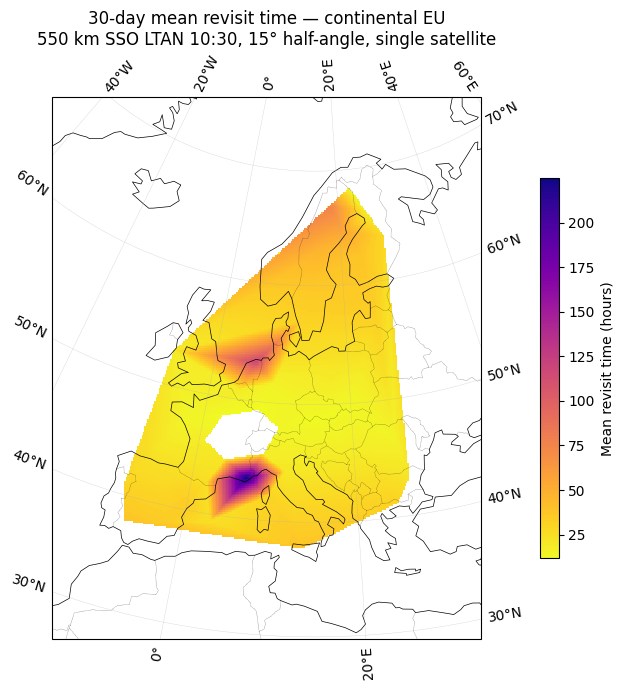

In [10]:
mean_rev_hrs = rev['mean_revisit'] / 3600.0

fig, ax = plt.subplots(
    figsize=(12, 7),
    subplot_kw={'projection': europe_proj},
)
plot_coverage_map(
    eu_continental,
    mean_rev_hrs,
    ax=ax,
    auto_window=True,
    cmap='plasma_r',
    colorbar_label='Mean revisit time (hours)',
    title=(
        '30-day mean revisit time — continental EU\n'
        '550 km SSO LTAN 10:30, 15° half-angle, single satellite'
    ),
)
plt.tight_layout()
plt.show()

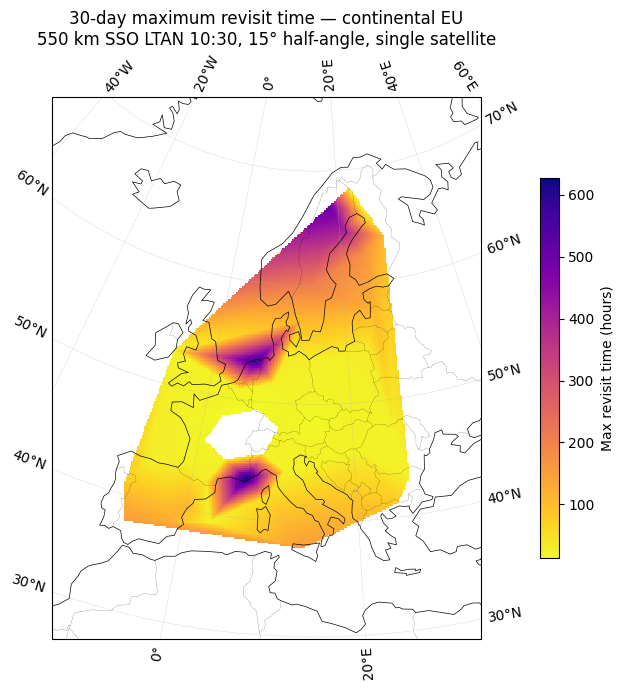

In [11]:
max_rev_hrs = rev['max_revisit'] / 3600.0

fig, ax = plt.subplots(
    figsize=(12, 7),
    subplot_kw={'projection': europe_proj},
)
plot_coverage_map(
    eu_continental,
    max_rev_hrs,
    ax=ax,
    auto_window=True,
    cmap='plasma_r',
    colorbar_label='Max revisit time (hours)',
    title=(
        '30-day maximum revisit time — continental EU\n'
        '550 km SSO LTAN 10:30, 15° half-angle, single satellite'
    ),
)
plt.tight_layout()
plt.show()